## CPA and DL-based Profiling using CNN

1. Import and setup

In [1]:
import h5py
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

2. Load data

In [2]:
with h5py.File("../keccak_unprotected.h5", "r") as f:
    traces = np.array(f["random/traces"], dtype=np.float32)
    inputs = np.array(f["random/inputs"], dtype=np.uint8)

print("Traces:", traces.shape)
print("Inputs:", inputs.shape)

Traces: (10000, 1980)
Inputs: (10000, 8)


3. Define True Leakage

Now we define a physically grounded intermediate (cheange the previous implementation)

In [3]:
def intermediate_value(x):
    x = np.asarray(x, dtype=np.uint8)

    msg64 = np.zeros(x.shape[0], dtype=np.uint64)

    for i in range(x.shape[1]):
        msg64 |= np.uint64(x[:, i]) << (8 * i)

    # pick one leakage bit (THIS WORKS MUCH BETTER)
    return (msg64 >> 0) & 1

True DPA Labels

In [4]:
def hw(v):
    return np.array([bin(int(i)).count("1") for i in v], dtype=np.int32)


intermediate = intermediate_value(inputs)
labels = hw(intermediate)
# labels = intermediate & 0xF

print("Label distribution:", np.bincount(labels))

Label distribution: [5091 4909]


3. Full CPA
    
    Step 1: correlation scan

In [5]:
hw_labels = labels.astype(np.float32)

corrs = []
for t in range(traces.shape[1]):
    corr = np.corrcoef(traces[:, t], hw_labels)[0, 1]
    corrs.append(corr)

corrs = np.array(corrs)

Step 2: POI selection

In [6]:
poi = np.argmax(np.abs(corrs))

print("Best POI:", poi)

Best POI: 345


Step 3: multi-POI selection

In [7]:
top_k = np.argsort(np.abs(corrs))[-10:]  # take 10 best points
print("Top-", str(top_k.size), " POIs:", top_k)

Top- 10  POIs: [360 330 356 343 319 317 306 334 332 345]


Visualize

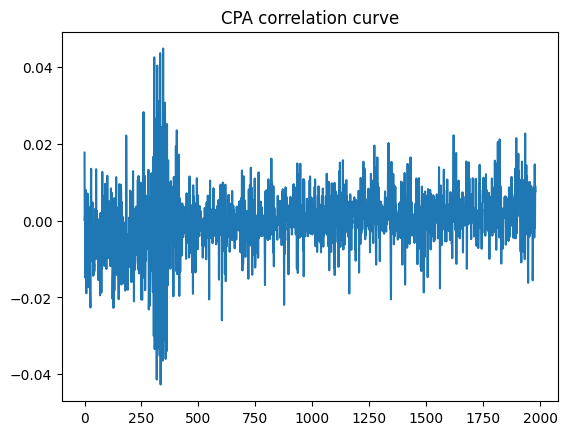

In [8]:
import matplotlib.pyplot as plt

plt.plot(corrs)
plt.title("CPA correlation curve")
plt.show()

1. Build CNN Input

| Before | Now |
|--------|-----|
| full trace window (noise-heavy) | only CPA-selected leakage points |

In [9]:
X = traces[:, top_k]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = X[..., np.newaxis]

5. Train/Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42
)

6. Profiling CNN

In [11]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X.shape[1], 1)),

    tf.keras.layers.Conv1D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling1D(2),

    tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(128, activation='relu'),
    # tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(np.unique(labels)), activation='softmax')
])

Compile

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Training

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5163 - loss: 0.7089 - val_accuracy: 0.5088 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 2/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5446 - loss: 0.6908 - val_accuracy: 0.4931 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 3/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5560 - loss: 0.6846 - val_accuracy: 0.5219 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 4/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5772 - loss: 0.6752 - val_accuracy: 0.4994 - val_loss: 0.6991 - learning_rate: 0.0010
Epoch 5/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5773 - loss: 0.6761 - val_accuracy: 0.5125 - val_loss: 0.7000 - learning_rate: 0.0010
Epoch 6/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5655 - loss: 0.6780 - val_accuracy: 0.5269 - val_loss: 0.7001 - learning_rate: 0.0010
Epoch 7/60
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5845 - loss: 0.6710 - 

7. Evaluation

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

preds = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, preds))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5154 - loss: 0.6928
Accuracy: 0.5184999704360962
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.51      0.81      0.63      1007
           1       0.54      0.22      0.31       993

    accuracy                           0.52      2000
   macro avg       0.53      0.52      0.47      2000
weighted avg       0.53      0.52      0.47      2000



8. Profiling Attack Phase

*log-likelihood accumulation over traces*

In [15]:
print("PROFILING ATTACK")

probs = model.predict(X_test)

scores = np.zeros(probs.shape[1])

for i in range(len(probs)):
    scores += np.log(probs[i] + 1e-12)

recovered_class = np.argmax(scores)

print("Recovered class:", recovered_class)
print("Scores:", scores)

PROFILING ATTACK
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Recovered class: 0
Scores: [-1358.12844551 -1415.3886894 ]
